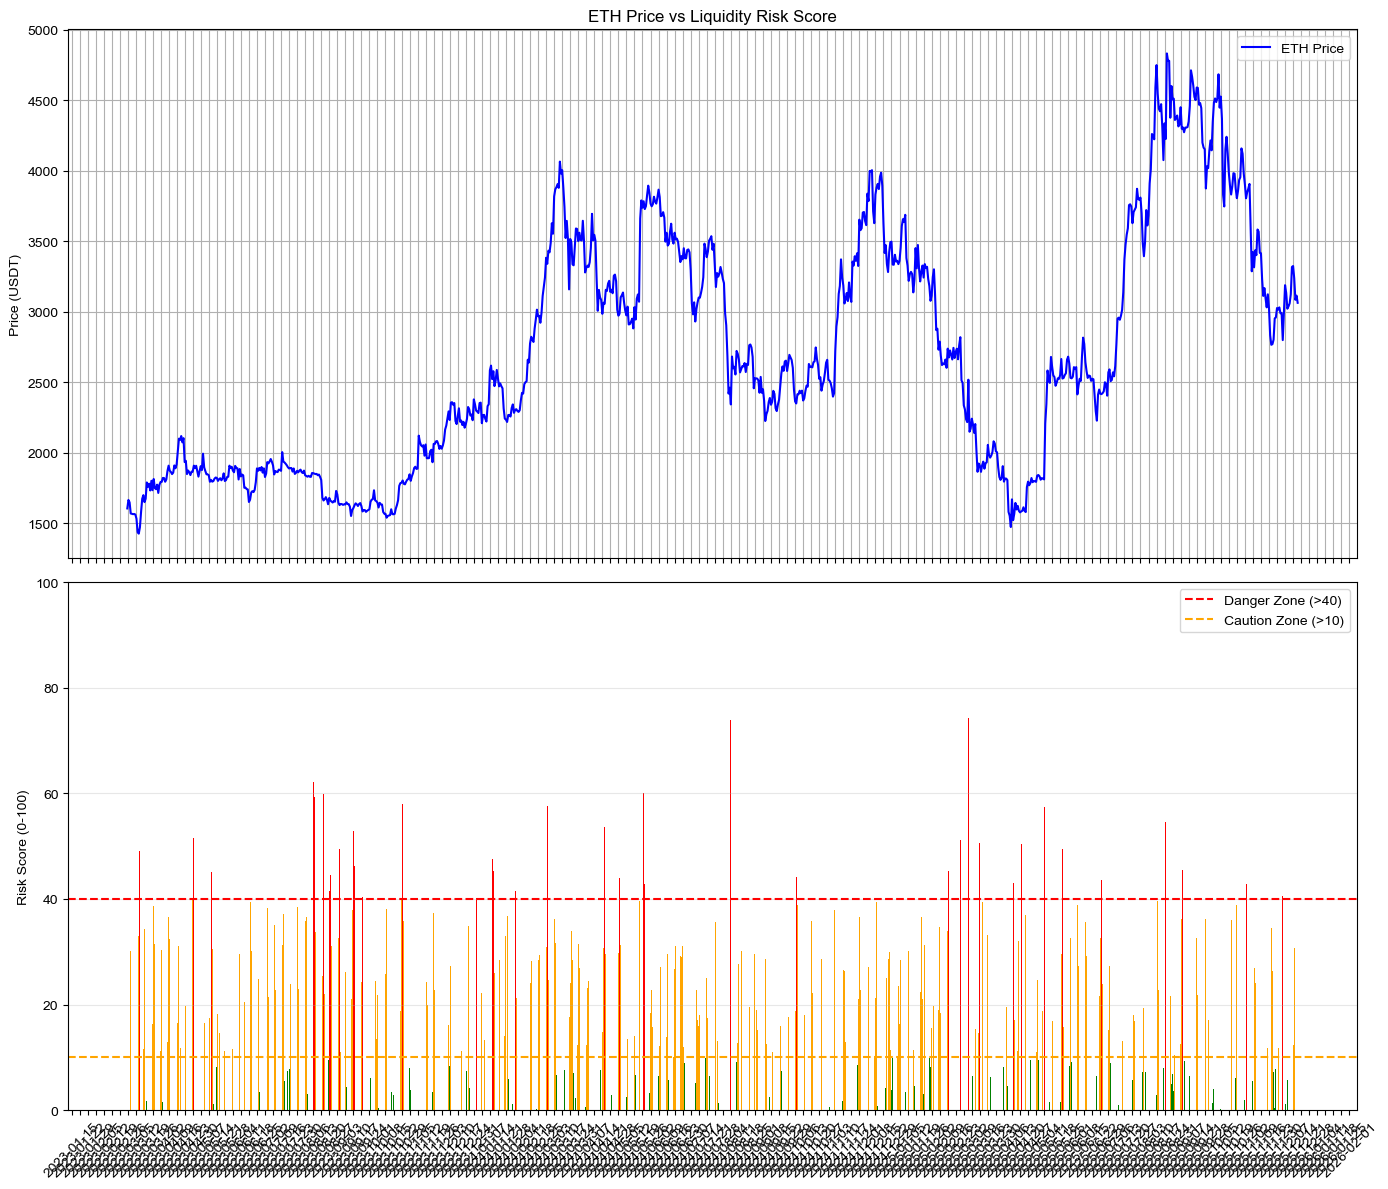

High Risk Days (Score > 10):
           date  open_price  fee_income  risk_score
3    2023-03-07     1569.45   27.862136   30.149428
10   2023-03-14     1426.43  169.398468   32.901221
11   2023-03-15     1471.93  134.001875   49.145698
14   2023-03-18     1699.41  137.181676   11.504178
15   2023-03-19     1649.95  102.521191   34.245799
...         ...         ...         ...         ...
1002 2025-11-30     3026.56   63.839228   30.046973
1003 2025-12-01     3015.23   64.664271   11.746509
1007 2025-12-05     2799.07   53.814507   40.614778
1016 2025-12-14     3324.14   71.396512   12.428076
1017 2025-12-15     3237.38   54.675974   30.770849

[281 rows x 4 columns]


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 1. Load Data (修改：读取新的单一数据源)
# 读取 backtest_results.csv
df = pd.read_csv('backtest_results.csv')

# 2. Process Dates (修改：适应新文件的日期格式)
# 新文件日期为标准 'YYYY-MM-DD' 格式，无需自定义解析函数
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# 映射列名以匹配原有逻辑
# 原逻辑使用 'fee_income'，新文件对应的是 'total_fee_usd'
df['fee_income'] = df['total_fee_usd']

# 3. Calculate Risk Score (保持不变)
# Use the formula: max(0, (0.85 - Ratio) / 0.85) * 100
df['fee_ma3_prev'] = df['fee_income'].shift(1).rolling(window=3).mean()
df['drop_ratio'] = df['fee_income'] / df['fee_ma3_prev']

threshold = 0.85

def calculate_risk_score(ratio):
    if pd.isna(ratio) or np.isinf(ratio):
        return 0
    score = (threshold - ratio) / threshold
    score = max(0, score)
    score = min(1, score)
    return score * 100

df['risk_score'] = df['drop_ratio'].apply(calculate_risk_score)

# 4. Prepare Plot Data (修改：不再需要 Merge，直接使用处理后的 df)
plot_df = df.copy()

# 5. Plotting (微调：使用新文件中的价格列 open_price)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Top Panel: Price
# 使用 open_price 代表 ETH 价格
ax1.plot(plot_df['date'], plot_df['open_price'], label='ETH Price', color='blue')
ax1.set_title('ETH Price vs Liquidity Risk Score')
ax1.set_ylabel('Price (USDT)')
ax1.legend()
ax1.grid(True)

# Bottom Panel: Risk Score (逻辑保持不变)
# Color bars based on risk level
colors = []
for score in plot_df['risk_score']:
    if score > 40:
        colors.append('red') # Danger
    elif score > 10:
        colors.append('orange') # Caution
    else:
        colors.append('green') # Safe

ax2.bar(plot_df['date'], plot_df['risk_score'], color=colors, width=0.8)
ax2.axhline(40, color='red', linestyle='--', label='Danger Zone (>40)')
ax2.axhline(10, color='orange', linestyle='--', label='Caution Zone (>10)')
ax2.set_ylabel('Risk Score (0-100)')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, axis='y', alpha=0.3)

# Format X axis dates
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d')) # 修改显示年份，因为数据跨度可能变了
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=7)) # Show date every week
plt.xticks(rotation=45)

plt.tight_layout()
# plt.savefig('eth_price_risk_score.png')
plt.show()

# 6. Output Table (保持不变，调整显示的列)
print("High Risk Days (Score > 10):")
# 显示日期、价格、费收入和风险分
risk_table = plot_df[plot_df['risk_score'] > 10][['date', 'open_price', 'fee_income', 'risk_score']]
print(risk_table)